# import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn
import scipy.stats

Some events form in different astrophysical environments than others. **You want to figure out how many of formation channels are at play.**


The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of $N$ gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$ and weight $\alpha_j$:

$p(x_i|\theta) = \sum_{j=1}^N \alpha_j \mathcal{N}(x_i| \mu_j,\sigma_j) $

This depends on $3N-1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability.)

#### Tasks

**1.** Load this file (`np.load`) and complete a quick exploration of the data. How many modes do you think you see?

**2.** We'll use `sklearn.mixture.GaussianMixture`. You first need to define the model (instance of a class), and then train it on the data using the `fit` method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.



<div class="alert alert-block alert-warning">
    
**Note**. We'll do a more formal introduction to scikit-learn in one of the next lectures. Today's exercise is meant to be a formative example on how you might find yourself dealing with a library you've never seen before. This happens *all the time* in research... (see the first lecture for more on my teaching style).

</div>


**3.** Complete the fit 10 times with $N=1,...,10$ Gaussians. 

Note: `sklearn` by default will use the so-called [Expectation-Maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm), which is one of the many great things in data science we don't have time to study in this class.

**4.** For each of these fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

**5.** Plot the preferred solution on top of the input data. You should get a very nice fit!

# code

(array([  1.,   0.,   1.,   1.,   1.,   1.,   3.,   3.,   1.,   4.,   1.,
          6.,   5.,   9.,   9.,   7.,  13.,  17.,  14.,   9.,  18.,  22.,
         16.,  15.,  17.,  19.,  16.,  14.,  17.,   9.,  22.,   4.,  12.,
         11.,   4.,   6.,  10.,  14.,  30.,  53., 108., 165., 138., 129.,
         56.,  40.,  35.,  51.,  50.,  60.,  43.,  79.,  68.,  87.,  75.,
         86.,  90.,  97.,  87.,  97.,  97.,  92.,  77.,  93.,  65.,  63.,
         69.,  47.,  52.,  38.,  31.,  29.,  38.,  16.,  16.,  16.,  13.,
          6.,   6.,   0.,   1.,   2.,   3.,   1.,   1.,   0.,   0.,   1.,
          0.,   1.]),
 array([-4.965425  , -4.36912867, -3.77283234, -3.17653602, -2.58023969,
        -1.98394336, -1.38764703, -0.7913507 , -0.19505438,  0.40124195,
         0.99753828,  1.59383461,  2.19013094,  2.78642726,  3.38272359,
         3.97901992,  4.57531625,  5.17161258,  5.7679089 ,  6.36420523,
         6.96050156,  7.55679789,  8.15309422,  8.74939054,  9.34568687,
         9.9419832 , 

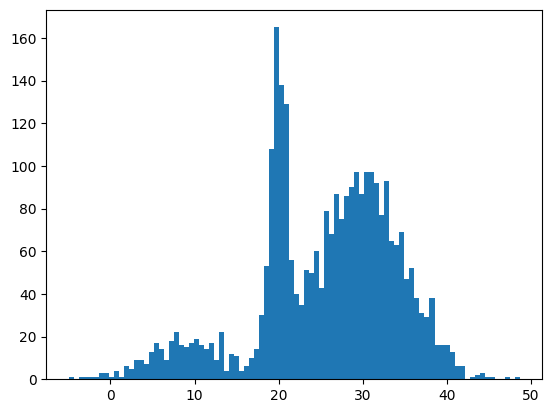

In [2]:
data = np.load('/home/matti/uni/astrostatistics_bicocca_2026/solutions/formationchannels.npy' )
# print (data)
plt.hist(data, 90)

probably there are 3 or 4 gaussians

In [25]:
aic= np.zeros(10)
for i in range (10):
    data_fit = sklearn.mixture.GaussianMixture(n_components=i+1).fit(data)
    aic[i] = data_fit.aic(data)
    m =  data_fit.means_
    s = data_fit.covariances_
    w = data_fit.weights_
    # print(s)

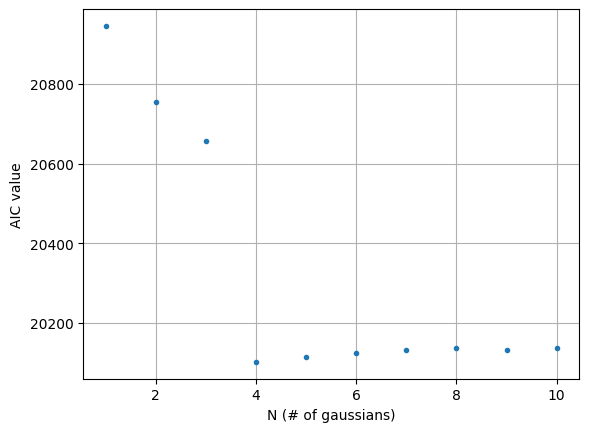

In [32]:
plt.plot(np.linspace(1, 10, 10), aic, '.')
plt.xlabel('N (# of gaussians)')
plt.ylabel('AIC value')
plt.grid()

the 4 components gaussianmixture has the lowest aic of all!!

lets see it visually

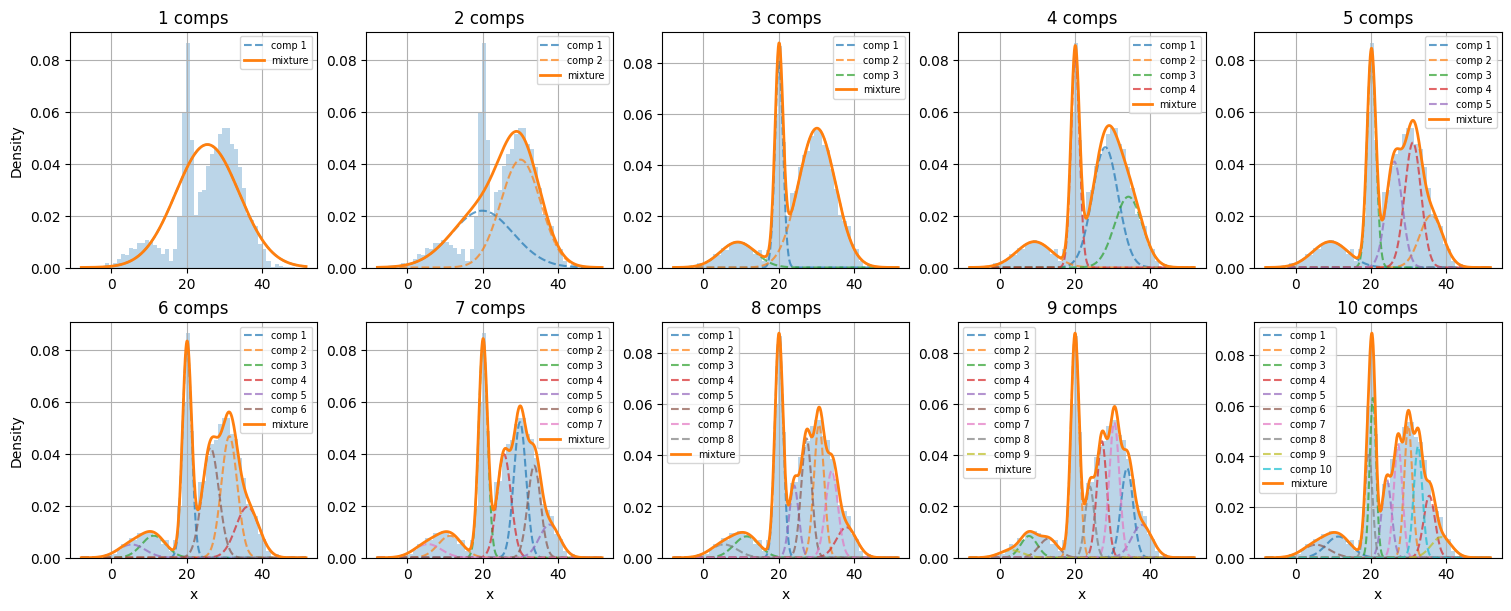

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), constrained_layout=True)
axes = axes.ravel()
x = np.linspace(data.min() - 3, data.max() + 3, 1000)

for i, ax in enumerate(axes):
    n_comp = i + 1
    data_fit = sklearn.mixture.GaussianMixture(n_components=n_comp)
    data_fit.fit(data)

    pdf = np.zeros_like(x)
    means = data_fit.means_.flatten()
    weights = data_fit.weights_.flatten()
    covs = data_fit.covariances_

    for k in range(n_comp):
        
        if covs.ndim == 3:
            var = float(covs[k].reshape(-1)[0])
        elif covs.ndim == 2:
            var = float(covs.reshape(-1)[0])
        else:
            var = float(covs[k])
        std = np.sqrt(var)
        pdf += weights[k] * scipy.stats.norm(loc=means[k], scale=std).pdf(x)
        ax.plot(x, weights[k] * scipy.stats.norm(loc=means[k], scale=std).pdf(x),
                linestyle='--', alpha=0.7, label=f'comp {k+1}')

    ax.hist(data.ravel(), bins=50, density=True, alpha=0.3, color='C0')
    ax.plot(x, pdf, color='C1', lw=2, label='mixture')
    ax.set_title(f'{n_comp} comps')
    ax.grid(True)
    if i % 5 == 0:
        ax.set_ylabel('Density')
    if i >= 5:
        ax.set_xlabel('x')
    ax.legend(fontsize='x-small')

plt.show()

#### [Optional tasks, not examinable] Class labels or "responsibilities"

Class labels are a very interesting by product of a mixture analysis. What is the probability that a given gravitational-wave event comes from a given channel? This is called "responsiblity" (i.e. which mode is most likely to be responsible for that piece of data). 

**6.** Understand (i.e. plot) which Gaussian mode corresponds to which part of the input dataset. 

*Hint:* Useful methods here are `score_samples` and `predict_proba`.
